# Waste YOLO — Baseline Error Analysis + Merged Dataset Training (CB+PAPER, no BIO)
This notebook:
1. Runs **error analysis** on the **original (old) dataset** (BIO excluded from metrics, paper separate).
2. Builds a **merged training dataset** (old + auxiliary) with:
   - BIODEGRADABLE removed
   - PAPER merged into CARDBOARD (cardboard_paper)
   - only {cardboard_paper, glass, metal, plastic}
3. Trains a new YOLOv8s model on the merged dataset and runs the same analytics on the merged validation split.


In [ ]:
!nvidia-smi

Mon Feb 23 20:39:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   32C    P0             70W /  700W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

True NVIDIA H100 80GB HBM3


In [ ]:
!pip -q install ultralytics opencv-python pyyaml pandas matplotlib
# If running on Colab:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import yaml
from ultralytics import YOLO

# -------------------
# USER CONFIG
# -------------------
DATASET_ROOT = Path("/content/drive/MyDrive/Waste")  # <-- change if needed
CACHE_DIR = DATASET_ROOT / "_pred_cache"  # prediction caches (JSONL), safe to keep on Drive
INFER_BATCH = 2  # keep small to avoid GPU OOM
DATA_YAML = DATASET_ROOT / "data.yaml"

# Baseline = your fine-tuned waste model weights (NOT yolov8s.pt COCO)
WEIGHTS_BASELINE = DATASET_ROOT / "yolov8s_best.pt"

# New model will be trained and saved under:
RUNS_DIR = Path("/content/drive/MyDrive/Waste/runs_waste_improve")

SPLIT_FOR_ANALYSIS = "valid"  # usually "valid"

CONF_THRES = 0.25
IOU_MATCH_THRES = 0.50

MAX_IMAGES_FOR_ANALYSIS = None  # set e.g. 500 for quick runs

# Improvement training settings
IMPROVE_IMGSZ = 896         # try 960 if GPU allows
IMPROVE_EPOCHS = 100
IMPROVE_PATIENCE = 10

# Augmentation knobs (Ultralytics)
IMPROVE_MOSAIC = 1.0         # strong early; you can set to 0.5 if too chaotic
IMPROVE_COPY_PASTE = 0.5     # increase if minority objects are rare
IMPROVE_MIXUP = 0.0          # usually keep 0 for detection unless you know you want it

# Non-overlap metric settings
ISOLATION_IOU_THRES = 0.05   # "isolated" if max IoU with any other GT < this

# =========================
# CACHE + RECOMPUTE FLAGS
# =========================

INFER_BATCH = 2                    # keep small for low memory
BASELINE_IMGSZ = 640               # evaluation resolution baseline
NEW_IMGSZ = 896                   # improved model resolution

print("DATASET_ROOT:", DATASET_ROOT)
print("DATA_YAML:", DATA_YAML)
print("Baseline weights:", WEIGHTS_BASELINE)

Mounted at /content/drive
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
DATASET_ROOT: /content/drive/MyDrive/Waste
DATA_YAML: /content/drive/MyDrive/Waste/data.yaml
Baseline weights: /content/drive/MyDrive/Waste/yolov8s_best.pt


## 1) Load YAML + define kept classes (drop BIODEGRADABLE)


In [ ]:

with open(DATA_YAML, "r") as f:
    data = yaml.safe_load(f)

names = data.get("names", [])
if isinstance(names, dict):
    names = [names[i] for i in sorted(names)]
names = list(names)

BIO_ID = 0  # BIODEGRADABLE
DROP_CLASS_IDS = {BIO_ID}
KEEP_CLASS_IDS = [i for i in range(len(names)) if i not in DROP_CLASS_IDS]

# compact mapping for plots (kept ids -> 0..K-1)
ID2K = {cid: k for k, cid in enumerate(KEEP_CLASS_IDS)}
K2ID = {k: cid for cid, k in ID2K.items()}
names_kept = [names[cid] for cid in KEEP_CLASS_IDS]

print("All classes:", list(enumerate(names)))
print("Keeping classes:", [(cid, names[cid]) for cid in KEEP_CLASS_IDS])


All classes: [(0, 'BIODEGRADABLE'), (1, 'CARDBOARD'), (2, 'GLASS'), (3, 'METAL'), (4, 'PAPER'), (5, 'PLASTIC')]
Keeping classes: [(1, 'CARDBOARD'), (2, 'GLASS'), (3, 'METAL'), (4, 'PAPER'), (5, 'PLASTIC')]


## 2) Helpers: listing, labels, geometry, matching



In [ ]:

def list_images(images_dir: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted([p for p in images_dir.rglob("*") if p.is_file() and p.suffix.lower() in exts])

def yolo_label_path_for_image(image_path: Path, labels_dir: Path) -> Path:
    return labels_dir / (image_path.stem + ".txt")

def read_yolo_labels(label_path: Path):
    if not label_path.exists():
        return np.zeros((0,5), float)
    txt = label_path.read_text().strip()
    if not txt:
        return np.zeros((0,5), float)
    rows = []
    for ln in txt.splitlines():
        parts = ln.strip().split()
        if len(parts) < 5:
            continue
        try:
            rows.append([float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])])
        except ValueError:
            continue
    if not rows:
        return np.zeros((0,5), float)
    return np.asarray(rows, float)

def xywhn_to_xyxy(xywhn, img_w, img_h):
    x, y, w, h = xywhn[:,0], xywhn[:,1], xywhn[:,2], xywhn[:,3]
    x1 = (x - w/2) * img_w
    y1 = (y - h/2) * img_h
    x2 = (x + w/2) * img_w
    y2 = (y + h/2) * img_h
    return np.stack([x1,y1,x2,y2], axis=1)

def box_iou_xyxy(a, b):
    if len(a)==0 or len(b)==0:
        return np.zeros((len(a), len(b)), float)
    ax1, ay1, ax2, ay2 = a[:,0:1], a[:,1:2], a[:,2:3], a[:,3:4]
    bx1, by1, bx2, by2 = b[:,0], b[:,1], b[:,2], b[:,3]
    inter_x1 = np.maximum(ax1, bx1)
    inter_y1 = np.maximum(ay1, by1)
    inter_x2 = np.minimum(ax2, bx2)
    inter_y2 = np.minimum(ay2, by2)
    inter_w = np.maximum(0.0, inter_x2 - inter_x1)
    inter_h = np.maximum(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h
    area_a = np.maximum(0.0, ax2-ax1) * np.maximum(0.0, ay2-ay1)
    area_b = np.maximum(0.0, bx2-bx1) * np.maximum(0.0, by2-by1)
    union = area_a + area_b - inter
    return (inter / np.maximum(union, 1e-9))

def extract_preds(result):
    h, w = result.orig_shape[0], result.orig_shape[1]
    if result.boxes is None or len(result.boxes) == 0:
        return np.zeros((0,4), float), np.zeros((0,), float), np.zeros((0,), int), w, h
    b = result.boxes
    boxes = b.xyxy.cpu().numpy()
    scores = b.conf.cpu().numpy()
    cls = b.cls.cpu().numpy().astype(int)

    # Drop BIODEGRADABLE predictions
    m = np.isin(cls, KEEP_CLASS_IDS)
    boxes, scores, cls = boxes[m], scores[m], cls[m]
    return boxes, scores, cls, w, h

def extract_gt(image_path: Path, labels_dir: Path, img_w, img_h):
    arr = read_yolo_labels(yolo_label_path_for_image(image_path, labels_dir))
    if len(arr) == 0:
        return np.zeros((0,4), float), np.zeros((0,), int)
    cls = arr[:,0].astype(int)
    boxes = xywhn_to_xyxy(arr[:,1:5], img_w, img_h)

    # Drop BIODEGRADABLE GT
    m = np.isin(cls, KEEP_CLASS_IDS)
    cls, boxes = cls[m], boxes[m]
    return boxes, cls

def greedy_match(gt_boxes, gt_cls, pred_boxes, pred_cls, pred_scores, iou_thres=0.5):
    iou = box_iou_xyxy(gt_boxes, pred_boxes)
    matched_gt, matched_pred = set(), set()
    matches = []
    if iou.size > 0:
        cand = np.argwhere(iou >= iou_thres)
        if len(cand):
            cand = cand[np.argsort(iou[cand[:,0], cand[:,1]])[::-1]]
            for gi, pj in cand:
                gi, pj = int(gi), int(pj)
                if gi in matched_gt or pj in matched_pred:
                    continue
                matched_gt.add(gi); matched_pred.add(pj)
                matches.append((gi, pj, float(iou[gi,pj]), int(gt_cls[gi]), int(pred_cls[pj]), float(pred_scores[pj])))
    gt_unmatched = [i for i in range(len(gt_boxes)) if i not in matched_gt]
    pred_unmatched = [j for j in range(len(pred_boxes)) if j not in matched_pred]
    return matches, gt_unmatched, pred_unmatched

def crowding_score(gt_boxes, iou_thres=0.2):
    n = len(gt_boxes)
    if n <= 1:
        return 0.0
    iou = box_iou_xyxy(gt_boxes, gt_boxes)
    np.fill_diagonal(iou, 0.0)
    overlapped = (iou >= iou_thres).any(axis=1)
    return float(overlapped.mean())

def size_bucket(area_frac):
    if area_frac < 0.02:
        return "small"
    if area_frac < 0.10:
        return "medium"
    return "large"

def isolated_mask(gt_boxes, iou_thres=0.05):
    n = len(gt_boxes)
    if n == 0:
        return np.zeros((0,), bool)
    if n == 1:
        return np.ones((1,), bool)
    iou = box_iou_xyxy(gt_boxes, gt_boxes)
    np.fill_diagonal(iou, 0.0)
    max_iou = iou.max(axis=1)
    return max_iou < iou_thres


## 3) Build image list for a split + quick split stats (kept classes only)


In [ ]:
import time

split_dir = DATASET_ROOT / SPLIT_FOR_ANALYSIS
images_dir = split_dir / "images"
labels_dir = split_dir / "labels"

assert images_dir.exists(), f"Missing: {images_dir}"
assert labels_dir.exists(), f"Missing: {labels_dir}"

image_files = list_images(images_dir)
if MAX_IMAGES_FOR_ANALYSIS:
    image_files = image_files[:MAX_IMAGES_FOR_ANALYSIS]

print(f"Split: {SPLIT_FOR_ANALYSIS} | images: {len(image_files)}")

images_with_class = {cid: 0 for cid in KEEP_CLASS_IDS}
instances_per_class = {cid: 0 for cid in KEEP_CLASS_IDS}

# ---- progress settings ----
PROGRESS_EVERY = 200  # print every N images (tune: 100/200/500)
t0 = time.time()

total = len(image_files)
for i, p in enumerate(image_files, start=1):
    # progress print
    if i == 1 or i % PROGRESS_EVERY == 0 or i == total:
        elapsed = time.time() - t0
        rate = i / elapsed if elapsed > 0 else 0.0
        eta = (total - i) / rate if rate > 0 else float("inf")
        print(f"  scanned {i}/{total} ({i/total*100:.1f}%) | "
              f"{rate:.2f} img/s | ETA {eta/60:.1f} min")

    arr = read_yolo_labels(yolo_label_path_for_image(p, labels_dir))
    if len(arr) == 0:
        continue

    cls = arr[:, 0].astype(int)
    cls = cls[np.isin(cls, KEEP_CLASS_IDS)]
    if len(cls) == 0:
        continue

    # images containing class (unique per image)
    for c in np.unique(cls):
        images_with_class[int(c)] += 1

    # total instances
    for c in cls:
        instances_per_class[int(c)] += 1

print("\nPer-class counts (kept classes only): images containing class | instances")
for cid in KEEP_CLASS_IDS:
    print(f"{cid:2d} {names[cid]:>10s}: {images_with_class[cid]:5d} | {instances_per_class[cid]:5d}")

Split: valid | images: 2098
  scanned 1/2098 (0.0%) | 4457.28 img/s | ETA 0.0 min
  scanned 200/2098 (9.5%) | 1.33 img/s | ETA 23.8 min
  scanned 400/2098 (19.1%) | 1.34 img/s | ETA 21.0 min
  scanned 600/2098 (28.6%) | 1.35 img/s | ETA 18.5 min
  scanned 800/2098 (38.1%) | 1.38 img/s | ETA 15.7 min
  scanned 1000/2098 (47.7%) | 1.38 img/s | ETA 13.3 min
  scanned 1200/2098 (57.2%) | 1.37 img/s | ETA 10.9 min
  scanned 1400/2098 (66.7%) | 1.37 img/s | ETA 8.5 min
  scanned 1600/2098 (76.3%) | 1.37 img/s | ETA 6.1 min
  scanned 1800/2098 (85.8%) | 1.37 img/s | ETA 3.6 min
  scanned 2000/2098 (95.3%) | 1.36 img/s | ETA 1.2 min
  scanned 2098/2098 (100.0%) | 1.36 img/s | ETA 0.0 min

Per-class counts (kept classes only): images containing class | instances
 1  CARDBOARD:   438 |  1292
 2      GLASS:   805 |  2380
 3      METAL:   398 |  1360
 4      PAPER:    15 |    33
 5    PLASTIC:    91 |   214


## 4) Inference + analysis builders


In [ ]:
import json, hashlib, gc, time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO

# -----------------------------------------------------------------------------
# CUDA/RAM-SAFE PREDICTION CACHING (JSONL)
# -----------------------------------------------------------------------------
# Why this exists:
# - Ultralytics can spike RAM if you pass a huge list of images at once.
# - We therefore run prediction in SMALL CHUNKS and write results to disk (jsonl)
#   as we go. Nothing big is kept in memory.
#
# Notes:
# - Use device="cpu" to avoid CUDA OOM during caching.
# - If you want GPU for caching, set device=0 and keep batch small (1-4).
# -----------------------------------------------------------------------------

def compute_cache_key(weights, image_files, conf, allowed_classes, imgsz):
    weights = Path(weights)
    weight_mtime = weights.stat().st_mtime if weights.exists() else 0
    payload = {
        "weights": str(weights),
        "weight_mtime": weight_mtime,
        "n_images": len(image_files),
        "conf": float(conf),
        "allowed_classes": sorted(allowed_classes) if allowed_classes else None,
        "imgsz": int(imgsz) if imgsz is not None else None,
    }
    raw = json.dumps(payload, sort_keys=True).encode()
    return hashlib.md5(raw).hexdigest()

def _chunker(seq, chunk_size):
    for i in range(0, len(seq), chunk_size):
        yield seq[i:i+chunk_size]

def predict_to_jsonl_cache_chunked(
    weights,
    image_files,
    cache_path,
    conf=0.25,
    allowed_classes=None,
    batch=1,
    imgsz=640,
    device="cpu",
    chunk_size=64,
    progress_every=200,
):
    """Run YOLO prediction in chunks and write one JSON per image to jsonl."""
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    model = YOLO(str(weights))
    n = len(image_files)
    t0 = time.time()
    done = 0

    with cache_path.open("w", encoding="utf-8") as f:
        for chunk in _chunker([str(p) for p in image_files], chunk_size):
            # stream=True keeps memory low, but chunking avoids huge internal lists
            stream = model.predict(
                source=chunk,
                conf=conf,
                classes=allowed_classes,
                batch=batch,
                imgsz=imgsz,
                device=device,
                stream=True,
                verbose=False,
            )
            for r in stream:
                boxes, scores, cls, w, h = extract_preds(r)
                rec = {
                    "image": str(Path(r.path)),
                    "w": int(w),
                    "h": int(h),
                    "boxes": boxes.tolist(),
                    "scores": scores.tolist(),
                    "cls": cls.tolist(),
                }
                f.write(json.dumps(rec) + "\n")
                done += 1

                if done == 1 or done % progress_every == 0 or done == n:
                    elapsed = time.time() - t0
                    rate = done / elapsed if elapsed > 0 else 0
                    eta = (n - done) / rate if rate > 0 else float("inf")
                    print(f"  cached {done}/{n} ({done/n*100:.1f}%) | {rate:.2f} img/s | ETA {eta/60:.1f} min")

            # aggressive cleanup between chunks (helps on Colab)
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
                torch.cuda.ipc_collect()

    # final cleanup
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

    print("Cache written:", cache_path, "| size (MB):", cache_path.stat().st_size / 1024**2)

def get_or_make_cache(
    weights,
    image_files,
    cache_dir,
    conf,
    allowed_classes,
    batch,
    imgsz,
    device="cpu",
    chunk_size=64,
):
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)

    key = compute_cache_key(weights, image_files, conf, allowed_classes, imgsz)
    cache_path = cache_dir / f"preds_{key}.jsonl"

    if cache_path.exists() and cache_path.stat().st_size > 0:
        print(f"Using existing cache: {cache_path}")
        return cache_path

    if cache_path.exists() and cache_path.stat().st_size == 0:
        print(f"Found EMPTY cache, rebuilding: {cache_path}")
        cache_path.unlink()

    print(f"Creating prediction cache: {cache_path}")
    predict_to_jsonl_cache_chunked(
        weights=weights,
        image_files=image_files,
        cache_path=cache_path,
        conf=conf,
        allowed_classes=allowed_classes,
        batch=batch,
        imgsz=imgsz,
        device=device,
        chunk_size=chunk_size,
    )
    return cache_path

def iter_preds_from_cache(cache_path):
    cache_path = Path(cache_path)
    with cache_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                yield json.loads(line)

def build_detection_dataframe_from_pred_records(
    pred_records,
    image_files,
    labels_dir: Path,
    iou_match=0.5,
    isolation_iou=0.05,
):
    rows_det = []
    rows_img = []

    image_set = {str(p): p for p in image_files}
    name_to_path = {Path(p).name: p for p in image_files}

    for rec in pred_records:
        img_key = rec.get("image", "")
        img_path = Path(img_key)

        if str(img_path) in image_set:
            img_path = image_set[str(img_path)]
        else:
            img_path = name_to_path.get(img_path.name, img_path)

        img_w, img_h = int(rec["w"]), int(rec["h"])
        pred_boxes = np.array(rec.get("boxes", []), dtype=float).reshape(-1, 4)
        pred_scores = np.array(rec.get("scores", []), dtype=float)
        pred_cls = np.array(rec.get("cls", []), dtype=int)

        gt_boxes, gt_cls = extract_gt(img_path, labels_dir, img_w, img_h)

        matches, gt_unm, pred_unm = greedy_match(
            gt_boxes, gt_cls, pred_boxes, pred_cls, pred_scores, iou_thres=iou_match
        )
        crowd = crowding_score(gt_boxes, iou_thres=0.2)

        iso = np.ones(len(gt_boxes), dtype=bool)
        if len(gt_boxes) > 1:
            iou_gg = box_iou_xyxy(gt_boxes, gt_boxes)
            np.fill_diagonal(iou_gg, 0.0)
            iso = (iou_gg.max(axis=1) < isolation_iou)

        rows_img.append({
            "image": str(img_path),
            "w": img_w,
            "h": img_h,
            "n_gt": int(len(gt_boxes)),
            "n_pred": int(len(pred_boxes)),
            "n_matches": int(len(matches)),
            "crowding": float(crowd),
        })

        for (gi, pj, iou, gcls, pcls, pscore) in matches:
            kind = "TP" if int(gcls) == int(pcls) else "CONFUSION"

            g_area = (gt_boxes[gi][2]-gt_boxes[gi][0]) * (gt_boxes[gi][3]-gt_boxes[gi][1])
            p_area = (pred_boxes[pj][2]-pred_boxes[pj][0]) * (pred_boxes[pj][3]-pred_boxes[pj][1])
            denom = (img_w * img_h) if (img_w * img_h) else 1.0

            rows_det.append({
                "image": str(img_path),
                "type": kind,
                "gt_cls": int(gcls),
                "pred_cls": int(pcls),
                "score": float(pscore),
                "iou": float(iou),
                "gt_area_frac": float(g_area / denom),
                "pred_area_frac": float(p_area / denom),
                "size_bucket": size_bucket(float(g_area / denom)),
                "crowding": float(crowd),
                "isolated_gt": bool(iso[gi]),
            })

        for gi in gt_unm:
            g_area = (gt_boxes[gi][2]-gt_boxes[gi][0]) * (gt_boxes[gi][3]-gt_boxes[gi][1])
            denom = (img_w * img_h) if (img_w * img_h) else 1.0

            rows_det.append({
                "image": str(img_path),
                "type": "FN",
                "gt_cls": int(gt_cls[gi]),
                "pred_cls": -1,
                "score": 0.0,
                "iou": 0.0,
                "gt_area_frac": float(g_area / denom),
                "pred_area_frac": 0.0,
                "size_bucket": size_bucket(float(g_area / denom)),
                "crowding": float(crowd),
                "isolated_gt": bool(iso[gi]),
            })

        for pj in pred_unm:
            p_area = (pred_boxes[pj][2]-pred_boxes[pj][0]) * (pred_boxes[pj][3]-pred_boxes[pj][1])
            denom = (img_w * img_h) if (img_w * img_h) else 1.0

            rows_det.append({
                "image": str(img_path),
                "type": "FP",
                "gt_cls": -1,
                "pred_cls": int(pred_cls[pj]),
                "score": float(pred_scores[pj]) if len(pred_scores) else 0.0,
                "iou": 0.0,
                "gt_area_frac": 0.0,
                "pred_area_frac": float(p_area / denom),
                "size_bucket": size_bucket(float(p_area / denom)),
                "crowding": float(crowd),
                "isolated_gt": False,
            })

    return pd.DataFrame(rows_det), pd.DataFrame(rows_img)


## 5) Baseline analysis (No BIO)


In [ ]:
def normalize_det_df(df):
    """
    Try to normalize different dataframe schemas into standard columns:
      type, gt_cls, pred_cls, score, iou, isolated_gt, gt_area_frac, pred_area_frac
    Returns a new dataframe with at least: type, gt_cls, pred_cls
    """
    df = df.copy()

    # Common alternative names
    rename_map = {}
    if "kind" in df.columns and "type" not in df.columns:
        rename_map["kind"] = "type"
    if "gt_class" in df.columns and "gt_cls" not in df.columns:
        rename_map["gt_class"] = "gt_cls"
    if "pred_class" in df.columns and "pred_cls" not in df.columns:
        rename_map["pred_class"] = "pred_cls"
    if "match_type" in df.columns and "type" not in df.columns:
        rename_map["match_type"] = "type"

    if rename_map:
        df = df.rename(columns=rename_map)

    # If still missing 'type', try to infer from boolean flags
    if "type" not in df.columns:
        # some pipelines store booleans like is_fp/is_fn/is_tp
        if all(c in df.columns for c in ["is_tp", "is_fp", "is_fn"]):
            df["type"] = np.where(df["is_tp"], "TP",
                           np.where(df["is_fp"], "FP",
                           np.where(df["is_fn"], "FN", "OTHER")))
        else:
            # Give up; caller will handle
            return df

    # Ensure required columns exist
    if "gt_cls" not in df.columns:
        # some FPs may use -1 and store gt in another field
        if "gt" in df.columns:
            df["gt_cls"] = df["gt"]
    if "pred_cls" not in df.columns:
        if "pred" in df.columns:
            df["pred_cls"] = df["pred"]

    return df


def summarize_per_class(df_det, keep_class_ids, names):
    df_det = normalize_det_df(df_det)

    missing = [c for c in ["type", "gt_cls", "pred_cls"] if c not in df_det.columns]
    if missing:
        raise KeyError(
            f"df_det is missing required columns {missing}. "
            f"Available columns: {list(df_det.columns)}"
        )

    rows = []
    for cid in keep_class_ids:
        tp = ((df_det["type"] == "TP") & (df_det["gt_cls"] == cid)).sum()
        fn = ((df_det["type"] == "FN") & (df_det["gt_cls"] == cid)).sum()

        fp = (
            ((df_det["type"] == "FP") & (df_det["pred_cls"] == cid)).sum()
            +
            ((df_det["type"] == "CONFUSION") & (df_det["pred_cls"] == cid)).sum()
        )

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        rows.append({
            "class_id": cid,
            "class": names[cid],
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "precision": round(float(precision), 4),
            "recall": round(float(recall), 4),
        })

    return pd.DataFrame(rows).sort_values("class_id")

def summarize_isolated_recall(df_det, keep_class_ids, names):
    rows = []

    for cid in keep_class_ids:
        iso_tp = (
            (df_det["type"] == "TP") &
            (df_det["gt_cls"] == cid) &
            (df_det["isolated_gt"] == True)
        ).sum()

        iso_fn = (
            (df_det["type"] == "FN") &
            (df_det["gt_cls"] == cid) &
            (df_det["isolated_gt"] == True)
        ).sum()

        iso_recall = iso_tp / (iso_tp + iso_fn) if (iso_tp + iso_fn) > 0 else 0.0

        rows.append({
            "class_id": cid,
            "class": names[cid],
            "isolated_recall": round(iso_recall, 4),
            "isolated_TP": int(iso_tp),
            "isolated_FN": int(iso_fn),
        })

    return pd.DataFrame(rows).sort_values("class_id")

In [ ]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()

m = YOLO(str(WEIGHTS_BASELINE))
print("Baseline nc:", m.model.nc)

cache_path_base = get_or_make_cache(
    weights=WEIGHTS_BASELINE,
    image_files=image_files,
    cache_dir=CACHE_DIR,
    conf=CONF_THRES,
    allowed_classes=KEEP_CLASS_IDS,
    batch=1,           # slow but safe
    imgsz=640,
    device="cpu",
    chunk_size=64       # force CPU to avoid CUDA OOM
)

from pathlib import Path
cache_path = Path(cache_path_base)
print("Cache path:", cache_path)
print("Cache exists:", cache_path.exists())
print("Cache size (MB):", cache_path.stat().st_size / 1024**2)

# show first 2 lines
with cache_path.open("r", encoding="utf-8") as f:
    for i in range(2):
        line = f.readline()
        print(f"line {i+1}:", line[:200], "..." if len(line) > 200 else "")

it = iter_preds_from_cache(cache_path_base)
first = next(it)
print("First record keys:", first.keys())
print("Example:", {k: first[k] for k in ["image","w","h"]})
print("#boxes:", len(first["boxes"]))

df_base_det, df_base_img = build_detection_dataframe_from_pred_records(
    pred_records=iter_preds_from_cache(cache_path_base),
    image_files=image_files,
    labels_dir=labels_dir,
    iou_match=IOU_MATCH_THRES,
    isolation_iou=ISOLATION_IOU_THRES
)

print("df_base_det:", df_base_det.shape, "columns:", list(df_base_det.columns))
print("df_base_img:", df_base_img.shape)
display(df_base_det.head())

Baseline nc: 6
Using existing cache: /content/drive/MyDrive/Waste/_pred_cache/preds_4e44775eeb2328d7537c69abfa1244fe.jsonl
Cache path: /content/drive/MyDrive/Waste/_pred_cache/preds_4e44775eeb2328d7537c69abfa1244fe.jsonl
Cache exists: True
Cache size (MB): 0.7970466613769531
line 1: {"image": "/content/drive/MyDrive/Waste/valid/images/biodegradable1000_jpg.rf.9407ff66b4ccd9f8eb5545be8f3225f4.jpg", "w": 416, "h": 416, "boxes": [], "scores": [], "cls": []}
 
line 2: {"image": "/content/drive/MyDrive/Waste/valid/images/biodegradable1004_jpg.rf.645d319975e53c260b201677f2f39981.jpg", "w": 416, "h": 416, "boxes": [], "scores": [], "cls": []}
 
First record keys: dict_keys(['image', 'w', 'h', 'boxes', 'scores', 'cls'])
Example: {'image': '/content/drive/MyDrive/Waste/valid/images/biodegradable1000_jpg.rf.9407ff66b4ccd9f8eb5545be8f3225f4.jpg', 'w': 416, 'h': 416}
#boxes: 0
df_base_det: (6553, 11) columns: ['image', 'type', 'gt_cls', 'pred_cls', 'score', 'iou', 'gt_area_frac', 'pred_area_frac',

,image,type,gt_cls,pred_cls,score,iou,gt_area_frac,pred_area_frac,size_bucket,crowding,isolated_gt
0,/content/drive/MyDrive/Waste/valid/images/biod...,FP,-1,2,0.779254,0.0,0.000000,0.019552,small,0.0,False
1,/content/drive/MyDrive/Waste/valid/images/biod...,FP,-1,5,0.349997,0.0,0.000000,0.970640,large,0.0,False
2,/content/drive/MyDrive/Waste/valid/images/biod...,FP,-1,2,0.331116,0.0,0.000000,0.039013,medium,0.0,False
3,/content/drive/MyDrive/Waste/valid/images/biod...,FP,-1,4,0.302299,0.0,0.000000,0.916844,large,0.0,False
4,/content/drive/MyDrive/Waste/valid/images/biod...,FN,4,-1,0.000000,0.0,0.056736,0.000000,medium,0.0,True


In [ ]:
import pandas as pd

def top_confusions(df, topn=15, true_col="gt_cls", pred_col="pred_cls"):
    # sanity checks
    missing = [c for c in [true_col, pred_col] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}. Available: {list(df.columns)}")

    df_wrong = df[df[true_col] != df[pred_col]]
    if df_wrong.empty:
        return pd.DataFrame(columns=[true_col, pred_col, "count"])

    return (
        df_wrong
        .groupby([true_col, pred_col])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(topn)
        .reset_index(drop=True)
    )

In [ ]:

print("Top FP classes:")
display(
    df_base_det[df_base_det["type"]=="FP"]
    .groupby(df_base_det["pred_cls"].map(lambda x: names[int(x)])).size()
    .sort_values(ascending=False).head(10)
    .reset_index(name="FP_count").rename(columns={"pred_cls":"class"})
)

print("\nTop FN classes:")
display(
    df_base_det[df_base_det["type"]=="FN"]
    .groupby(df_base_det["gt_cls"].map(lambda x: names[int(x)])).size()
    .sort_values(ascending=False).head(10)
    .reset_index(name="FN_count").rename(columns={"gt_cls":"class"})
)

print(df_base_det.columns)

print("\nTop confusions:")
display(top_confusions(df_base_det, topn=15))


Top FP classes:


,class,FP_count
0,CARDBOARD,447
1,GLASS,367
2,METAL,271
3,PLASTIC,133
4,PAPER,56



Top FN classes:


,class,FN_count
0,GLASS,562
1,CARDBOARD,519
2,METAL,439
3,PLASTIC,87
4,PAPER,26


Index(['image', 'type', 'gt_cls', 'pred_cls', 'score', 'iou', 'gt_area_frac',
       'pred_area_frac', 'size_bucket', 'crowding', 'isolated_gt'],
      dtype='object')

Top confusions:


,gt_cls,pred_cls,count
0,2,-1,562
1,1,-1,519
2,-1,1,447
3,3,-1,439
4,-1,2,367
5,-1,3,271
6,-1,5,133
7,5,-1,87
8,-1,4,56
9,2,3,43


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_recall_by_bucket(df, title="Recall proxy by size bucket"):
    """
    Recall proxy = correct detections / total GT per size bucket
    """

    df = df.copy()
    df["correct"] = df["gt_cls"] == df["pred_cls"]

    summary = (
        df.groupby("size_bucket")
          .agg(total=("gt_cls", "count"),
               correct=("correct", "sum"))
          .reset_index()
    )

    summary["recall_proxy"] = summary["correct"] / summary["total"]

    plt.figure()
    plt.bar(summary["size_bucket"].astype(str), summary["recall_proxy"])
    plt.title(title)
    plt.xlabel("Size bucket")
    plt.ylabel("Recall proxy")
    plt.xticks(rotation=45)
    plt.show()

    return summary

def plot_recall_vs_crowding(df, title="Recall proxy vs crowding"):
    df = df.copy()
    df["correct"] = df["gt_cls"] == df["pred_cls"]

    summary = (
        df.groupby("crowding")
          .agg(total=("gt_cls", "count"),
               correct=("correct", "sum"))
          .reset_index()
    )

    summary["recall_proxy"] = summary["correct"] / summary["total"]

    plt.figure()
    plt.plot(summary["crowding"], summary["recall_proxy"])
    plt.title(title)
    plt.xlabel("Crowding")
    plt.ylabel("Recall proxy")
    plt.show()

    return summary

def isolated_metric(df):
    """
    Computes recall proxy per class for isolated ground-truth objects.
    """

    df_iso = df[df["isolated_gt"] == True].copy()
    df_iso["correct"] = df_iso["gt_cls"] == df_iso["pred_cls"]

    summary = (
        df_iso.groupby("gt_cls")
              .agg(total=("gt_cls", "count"),
                   correct=("correct", "sum"))
              .reset_index()
    )

    summary["recall_proxy"] = summary["correct"] / summary["total"]

    return summary.sort_values("recall_proxy")

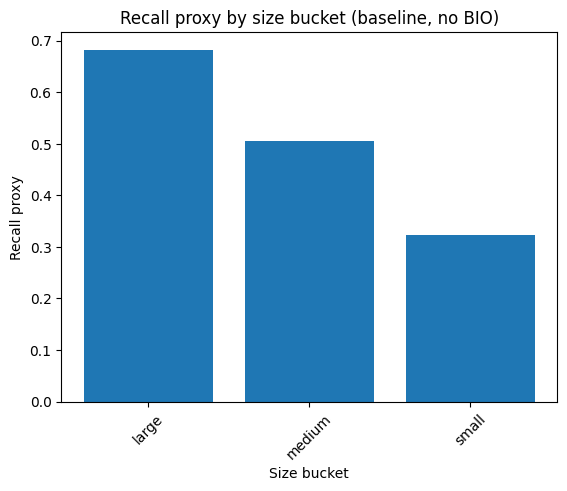

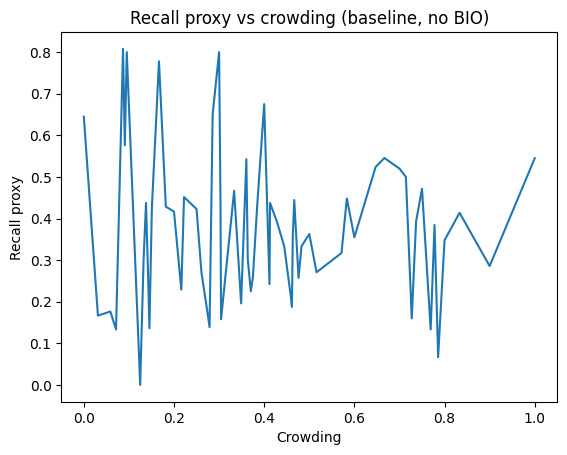


Isolated (non-overlapping GT) recall proxy per class (baseline):


,gt_cls,total,correct,recall_proxy
3,4,19,3,0.157895
4,5,164,94,0.573171
2,3,748,475,0.635027
0,1,505,337,0.667327
1,2,1342,1150,0.856930


In [ ]:

_ = plot_recall_by_bucket(df_base_det, "Recall proxy by size bucket (baseline, no BIO)")
_ = plot_recall_vs_crowding(df_base_det, "Recall proxy vs crowding (baseline, no BIO)")

print("\nIsolated (non-overlapping GT) recall proxy per class (baseline):")
df_iso_base = isolated_metric(df_base_det)
df_iso_base


## 6A) Auxiliary dataset + merged 4-class dataset
We build a **new merged dataset** (old + auxiliary) for training with:
- BIODEGRADABLE dropped
- PAPER merged into CARDBOARD (cardboard_paper)
- only 4 classes: cardboard_paper, glass, metal, plastic


In [ ]:
from pathlib import Path
import yaml, shutil, time

AUX_ROOT = DATASET_ROOT / "auxiliary_dataset"

# Outputs (new)
OLD4_ROOT   = DATASET_ROOT / "old_4c_cbpaper_no_bio"
AUX4_ROOT   = DATASET_ROOT / "aux_4c_cbpaper_no_bio"
MERGED4_ROOT = DATASET_ROOT / "merged_old_plus_aux_4c_cbpaper_no_bio"
MERGED4_DATA_YAML = MERGED4_ROOT / "data.yaml"

SKIP_IF_EXISTS = True
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("\n========== BUILD MERGED 4-CLASS DATASET ==========\n")

def _list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted([p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS])

def _normalize_names_map(names):
    if isinstance(names, list):
        id2name = {i:n for i,n in enumerate(names)}
    elif isinstance(names, dict):
        id2name = {int(k): v for k,v in names.items()}
    else:
        raise ValueError("Unexpected names type in YAML")
    name2id = {str(v).strip().lower(): int(k) for k,v in id2name.items()}
    return id2name, name2id

def _write_yaml(root: Path, names_list):
    out_yaml = {
        "path": str(root),
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "names": names_list
    }
    (root / "data.yaml").write_text(yaml.safe_dump(out_yaml, sort_keys=False))

# Old dataset class ids (from DATA_YAML)
with open(DATA_YAML, "r") as f:
    old_yaml = yaml.safe_load(f)
old_id2name, old_name2id = _normalize_names_map(old_yaml.get("names", []))

# Aux dataset class ids (from AUX data.yaml)
aux_yaml_path = AUX_ROOT / "data.yaml"
assert aux_yaml_path.exists(), f"Missing aux data.yaml: {aux_yaml_path}"
aux_yaml = yaml.safe_load(aux_yaml_path.read_text())
aux_id2name, aux_name2id = _normalize_names_map(aux_yaml.get("names", []))

# Target 4-class names
NAMES_4C = ["cardboard_paper", "glass", "metal", "plastic"]

# Build remaps -> 4-class ids: 0 cb_paper, 1 glass, 2 metal, 3 plastic
# OLD expected: bio=0, cardboard=1, glass=2, metal=3, paper=4, plastic=5
need_old = ["cardboard", "paper", "glass", "metal", "plastic", "biodegradable"]
missing_old = [n for n in need_old if n not in old_name2id]
if missing_old:
    print("[WARN] Old yaml missing:", missing_old, "Found:", list(old_name2id.keys()))

old_map = {}
if "cardboard" in old_name2id: old_map[old_name2id["cardboard"]] = 0
if "paper" in old_name2id:     old_map[old_name2id["paper"]]     = 0
if "glass" in old_name2id:     old_map[old_name2id["glass"]]     = 1
if "metal" in old_name2id:     old_map[old_name2id["metal"]]     = 2
if "plastic" in old_name2id:   old_map[old_name2id["plastic"]]   = 3
# ignore biodegradable and anything else by dropping unmapped ids

# AUX expected: paper, plastic, glass, metal (+ other classes to drop)
aux_map = {}
if "paper" in aux_name2id:   aux_map[aux_name2id["paper"]]   = 0
if "glass" in aux_name2id:   aux_map[aux_name2id["glass"]]   = 1
if "metal" in aux_name2id:   aux_map[aux_name2id["metal"]]   = 2
if "plastic" in aux_name2id: aux_map[aux_name2id["plastic"]] = 3

print("Old class ids:", old_name2id)
print("Aux class ids:", aux_name2id)
print("Old->4C map:", old_map)
print("Aux->4C map:", aux_map)

def remap_dataset_to_4c(src_root: Path, dst_root: Path, id_map: dict, tag: str):
    if (dst_root / "data.yaml").exists() and SKIP_IF_EXISTS:
        print(f"[SKIP] {tag}: exists at {dst_root}")
        return

    if dst_root.exists():
        shutil.rmtree(dst_root)

    total_imgs = 0
    kept_boxes = 0

    for split in ["train", "valid", "test"]:
        (dst_root/split/"images").mkdir(parents=True, exist_ok=True)
        (dst_root/split/"labels").mkdir(parents=True, exist_ok=True)

        in_img = src_root/split/"images"
        in_lbl = src_root/split/"labels"
        if not in_img.exists():
            print(f"[WARN] {tag}: missing split {split} ({in_img})")
            continue

        imgs = _list_images(in_img)
        print(f"{tag} {split}: {len(imgs)} images")

        for i, p in enumerate(imgs, 1):
            total_imgs += 1

            dst_img = dst_root/split/"images"/p.name
            if dst_img.exists():
                dst_img = dst_root/split/"images"/f"{tag}_{p.name}"
            shutil.copy2(p, dst_img)

            src_lbl = in_lbl/(p.stem + ".txt")
            dst_lbl = dst_root/split/"labels"/(dst_img.stem + ".txt")

            if not src_lbl.exists():
                dst_lbl.write_text("")
                continue

            new_lines = []
            for ln in src_lbl.read_text().splitlines():
                parts = ln.strip().split()
                if len(parts) != 5:
                    continue
                cls = int(float(parts[0]))
                if cls not in id_map:
                    continue
                parts[0] = str(id_map[cls])
                new_lines.append(" ".join(parts))
                kept_boxes += 1

            dst_lbl.write_text(("\n".join(new_lines) + "\n") if new_lines else "")

            if i % 500 == 0:
                print(f"  {tag} {split}: {i}/{len(imgs)}")

    _write_yaml(dst_root, NAMES_4C)
    print(f"{tag}: done | images={total_imgs} | kept_boxes={kept_boxes}")

def merge_two_yolo_datasets(root_a: Path, root_b: Path, out_root: Path):
    if (out_root / "data.yaml").exists() and SKIP_IF_EXISTS:
        print(f"[SKIP] MERGED: exists at {out_root}")
        return

    if out_root.exists():
        shutil.rmtree(out_root)

    total_a = 0
    total_b = 0

    for split in ["train", "valid", "test"]:
        (out_root/split/"images").mkdir(parents=True, exist_ok=True)
        (out_root/split/"labels").mkdir(parents=True, exist_ok=True)

        for prefix, src_root in [("old", root_a), ("aux", root_b)]:
            src_images = src_root/split/"images"
            src_labels = src_root/split/"labels"
            imgs = _list_images(src_images)
            print(f"MERGE {split}: {prefix} {len(imgs)} images")

            for i, p in enumerate(imgs, 1):
                dst_img = out_root/split/"images"/f"{prefix}_{p.name}"
                shutil.copy2(p, dst_img)

                src_lbl = src_labels/(p.stem + ".txt")
                dst_lbl = out_root/split/"labels"/(dst_img.stem + ".txt")
                if src_lbl.exists():
                    shutil.copy2(src_lbl, dst_lbl)
                else:
                    dst_lbl.write_text("")

                if prefix == "old":
                    total_a += 1
                else:
                    total_b += 1

                if i % 500 == 0:
                    print(f"  MERGE {split} {prefix}: {i}/{len(imgs)}")

    _write_yaml(out_root, NAMES_4C)
    print(f"MERGED: done | old_images={total_a} | aux_images={total_b} | total={total_a+total_b}")

t0 = time.time()

remap_dataset_to_4c(DATASET_ROOT, OLD4_ROOT, old_map, tag="OLD4")
remap_dataset_to_4c(AUX_ROOT, AUX4_ROOT, aux_map, tag="AUX4")
merge_two_yolo_datasets(OLD4_ROOT, AUX4_ROOT, MERGED4_ROOT)

print("\nMerged 4-class YAML:", MERGED4_DATA_YAML)
print("Finished in", round(time.time() - t0, 2), "sec")



========== BUILD MERGED 4-CLASS DATASET ==========

Old class ids: {'biodegradable': 0, 'cardboard': 1, 'glass': 2, 'metal': 3, 'paper': 4, 'plastic': 5}
Aux class ids: {'paper': 0, 'plastic': 1, 'glass': 2, 'metal': 3, 'organic': 4, 'electronics': 5, 'miscellaneous': 6}
Old->4C map: {1: 0, 4: 0, 2: 1, 3: 2, 5: 3}
Aux->4C map: {0: 0, 2: 1, 3: 2, 1: 3}
[SKIP] OLD4: exists at /content/drive/MyDrive/Waste/old_4c_cbpaper_no_bio
[SKIP] AUX4: exists at /content/drive/MyDrive/Waste/aux_4c_cbpaper_no_bio
[SKIP] MERGED: exists at /content/drive/MyDrive/Waste/merged_old_plus_aux_4c_cbpaper_no_bio

Merged 4-class YAML: /content/drive/MyDrive/Waste/merged_old_plus_aux_4c_cbpaper_no_bio/data.yaml
Finished in 0.0 sec


In [ ]:
# -----------------------------------------------------------------------------
# 6) Train improved model (CUDA/RAM-safe defaults)
# -----------------------------------------------------------------------------
# Main causes of crashes during training:
# - imgsz too large for GPU VRAM
# - batch too large for GPU VRAM
# - cache='ram' (or big dataloader workers) exhausting host RAM
#
# This training call sets conservative defaults:
# - cache=False  (do NOT preload all images into RAM)
# - workers=2    (lower host RAM pressure)
# - batch=8      (lower VRAM pressure; increase only if stable)
# - amp=True     (mixed precision on GPU -> less VRAM)
#
# If you STILL get CUDA OOM:
#   1) reduce batch (e.g. 2 or 1)
#   2) reduce imgsz (e.g. 640)
# -----------------------------------------------------------------------------

import torch
RUNS_DIR.mkdir(parents=True, exist_ok=True)

train_device = 0 if torch.cuda.is_available() else "cpu"
print("Training device:", train_device)

yolo2 = YOLO("yolov8s.pt")
train_res = yolo2.train(
    data=str(MERGED4_DATA_YAML),
    imgsz=640,
    epochs=IMPROVE_EPOCHS,
    patience=IMPROVE_PATIENCE,
    project=str(RUNS_DIR),
    name="yolov8s_merged4c_img640",
    copy_paste=0.0,
    mosaic=0,
    close_mosaic=0,
    mixup=0.0,
    multi_scale=False,
    cache=False,                 # <<< IMPORTANT: prevents host RAM blow-ups
    workers=8,                   # keep low (Colab RAM-safe)
    batch=64,                     # keep low (VRAM-safe). If stable, try 8.
    amp=True,                    # mixed precision on GPU
    device=train_device,
    verbose=True
)

print("Training done. Runs:", RUNS_DIR)


Training device: 0
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Waste/merged_old_plus_aux_4c_cbpaper_no_bio/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0, multi_scale=False, name=yolov8s_merged4c_img6408, nbs=64, nms=

## 7) New model analysis on merged 4-class validation set


In [ ]:
from pathlib import Path
import yaml

# Load merged4 YAML and resolve paths
merged4_yaml = yaml.safe_load(Path(MERGED4_DATA_YAML).read_text())
merged4_root = Path(merged4_yaml.get("path", Path(MERGED4_DATA_YAML).parent)).resolve()

val_images_rel = merged4_yaml.get("val", merged4_yaml.get("valid", None))
assert val_images_rel is not None, "MERGED4 yaml missing 'val' (or 'valid')"

val_images_dir = Path(val_images_rel)
if not val_images_dir.is_absolute():
    val_images_dir = (merged4_root / val_images_dir).resolve()

val_labels_dir = val_images_dir.parent / "labels"   # .../valid/images -> .../valid/labels

print("MERGED4 val_images_dir:", val_images_dir)
print("MERGED4 val_labels_dir:", val_labels_dir)

# Build image list for merged validation
image_files_merged = list_images(val_images_dir)  # uses your existing helper
print("Merged val images:", len(image_files_merged))

MERGED4 val_images_dir: /content/drive/MyDrive/Waste/merged_old_plus_aux_4c_cbpaper_no_bio/valid/images
MERGED4 val_labels_dir: /content/drive/MyDrive/Waste/merged_old_plus_aux_4c_cbpaper_no_bio/valid/labels
Merged val images: 4401


In [ ]:
import time, itertools

def iter_preds_with_progress(cache_path, every=200):
    t0 = time.time()
    for i, rec in enumerate(iter_preds_from_cache(cache_path), 1):
        if i % every == 0:
            dt = time.time() - t0
            print(f"Read {i} pred records | {i/dt:.1f} rec/s | elapsed {dt/60:.2f} min")
        yield rec

# quick sanity: count files
print("Num merged val images:", len(image_files_merged))

Num merged val images: 4401


In [ ]:
# Find latest best.pt under RUNS_DIR (your new training run)
from pathlib import Path
cands = sorted(RUNS_DIR.rglob("weights/best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
assert len(cands) > 0, f"No best.pt found under {RUNS_DIR}"
WEIGHTS_NEW = cands[0]
print("Using WEIGHTS_NEW:", WEIGHTS_NEW)

import gc, torch
gc.collect()
torch.cuda.empty_cache()

# Cache predictions for the new model too (kept classes only, no BIO)
# Keep device='cpu' + small batches to avoid CUDA OOM, and chunk to avoid RAM spikes.
cache_path_new = get_or_make_cache(
    weights=WEIGHTS_NEW,
    image_files=image_files_merged,
    cache_dir=CACHE_DIR,
    conf=CONF_THRES,
    allowed_classes=KEEP_CLASS_IDS,
    batch=32,          # try 64 on H100 if stable
    imgsz=640,
    device=0,          # <-- GPU
    chunk_size=512     # fewer chunks = less overhead
)

df_new_det, df_new_img = build_detection_dataframe_from_pred_records(
    pred_records=iter_preds_with_progress(cache_path_new, every=200),
    image_files=image_files_merged,
    labels_dir=val_labels_dir,
    iou_match=IOU_MATCH_THRES,
    isolation_iou=ISOLATION_IOU_THRES
)

print("df_new_det:", df_new_det.shape, "df_new_img:", df_new_img.shape)
display(df_new_det.head())


Using WEIGHTS_NEW: /content/drive/MyDrive/Waste/runs_waste_improve/yolov8s_merged4c_img6408/weights/best.pt
Using existing cache: /content/drive/MyDrive/Waste/_pred_cache/preds_274a05d33ffed09ad03fc03012715a3c.jsonl
Read 200 pred records | 845.2 rec/s | elapsed 0.00 min
Read 400 pred records | 860.9 rec/s | elapsed 0.01 min
Read 600 pred records | 872.2 rec/s | elapsed 0.01 min
Read 800 pred records | 869.5 rec/s | elapsed 0.02 min
Read 1000 pred records | 867.3 rec/s | elapsed 0.02 min
Read 1200 pred records | 863.7 rec/s | elapsed 0.02 min
Read 1400 pred records | 864.5 rec/s | elapsed 0.03 min
Read 1600 pred records | 860.6 rec/s | elapsed 0.03 min
Read 1800 pred records | 856.7 rec/s | elapsed 0.04 min
Read 2000 pred records | 856.7 rec/s | elapsed 0.04 min
Read 2200 pred records | 858.6 rec/s | elapsed 0.04 min
Read 2400 pred records | 872.7 rec/s | elapsed 0.05 min
Read 2600 pred records | 882.2 rec/s | elapsed 0.05 min
Read 2800 pred records | 888.7 rec/s | elapsed 0.05 min
Read

,image,type,gt_cls,pred_cls,score,iou,gt_area_frac,pred_area_frac,size_bucket,crowding,isolated_gt
0,/content/drive/MyDrive/Waste/merged_old_plus_a...,TP,2,2,0.758832,0.827048,0.095402,0.085228,medium,0.0,True
1,/content/drive/MyDrive/Waste/merged_old_plus_a...,FN,3,-1,0.000000,0.000000,0.346004,0.000000,large,0.0,True
2,/content/drive/MyDrive/Waste/merged_old_plus_a...,FP,-1,3,0.365549,0.000000,0.000000,0.034293,medium,0.0,False
3,/content/drive/MyDrive/Waste/merged_old_plus_a...,TP,3,3,0.802382,0.829898,0.117992,0.107587,large,0.0,True
4,/content/drive/MyDrive/Waste/merged_old_plus_a...,CONFUSION,3,1,0.558636,0.868379,0.366928,0.368347,large,0.0,True


Top confusions (new):


,gt_cls,pred_cls,count
0,-1,3,745
1,1,-1,736
2,2,-1,616
3,3,-1,443
4,-1,2,442
5,-1,1,389
6,1,3,46
7,2,3,36
8,3,2,36
9,1,2,32


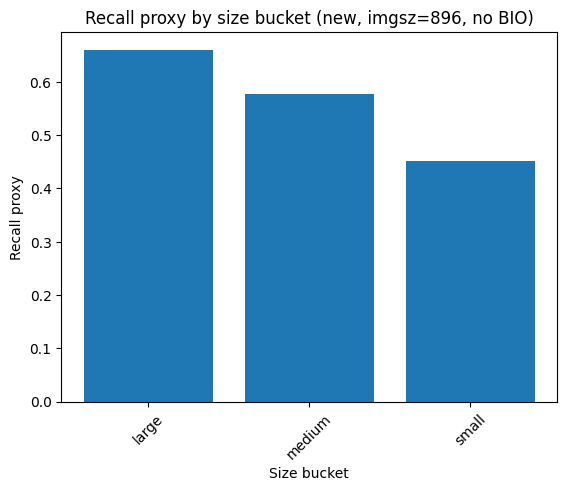

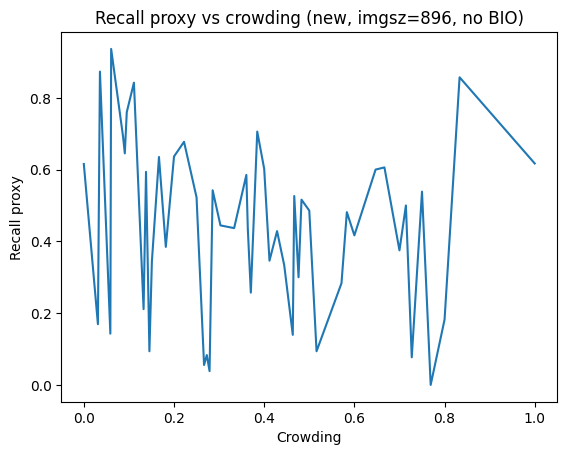


Isolated (non-overlapping GT) recall proxy per class (new):


,gt_cls,total,correct,recall_proxy
1,2,1228,826,0.672638
0,1,1459,1173,0.803975
2,3,1996,1659,0.831162


In [ ]:

print("Top confusions (new):")
display(top_confusions(df_new_det, topn=15))

_ = plot_recall_by_bucket(df_new_det, f"Recall proxy by size bucket (new, imgsz={IMPROVE_IMGSZ}, no BIO)")
_ = plot_recall_vs_crowding(df_new_det, f"Recall proxy vs crowding (new, imgsz={IMPROVE_IMGSZ}, no BIO)")

print("\nIsolated (non-overlapping GT) recall proxy per class (new):")
df_iso_new = isolated_metric(df_new_det)
df_iso_new


## 8) Compare baseline vs new


In [ ]:
import pandas as pd

def per_class_metrics_at_iou(df, iou_thr=0.5):
    df = df.copy()

    # a detection is "correct" only if class matches AND IoU passes threshold
    df["tp"] = (df["gt_cls"] == df["pred_cls"]) & (df["iou"] >= iou_thr)

    classes = sorted(set(df["gt_cls"]).union(set(df["pred_cls"])))
    rows = []

    for cls in classes:
        tp = ((df["gt_cls"] == cls) & (df["pred_cls"] == cls) & (df["iou"] >= iou_thr)).sum()
        fp = ((df["pred_cls"] == cls) & (~((df["gt_cls"] == cls) & (df["iou"] >= iou_thr)))).sum()
        fn = ((df["gt_cls"] == cls) & (~((df["pred_cls"] == cls) & (df["iou"] >= iou_thr)))).sum()

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

        rows.append({
            "class": cls,
            "precision@iou": precision,
            "recall@iou": recall,
            "f1@iou": f1,
            "support": (df["gt_cls"] == cls).sum()
        })

    return pd.DataFrame(rows)

In [ ]:
df_base_cls = per_class_metrics_at_iou(df_base_det, iou_thr=0.5)
df_new_cls  = per_class_metrics_at_iou(df_new_det,  iou_thr=0.5)

base = df_base_cls.set_index("class").add_prefix("base_")
new  = df_new_cls.set_index("class").add_prefix("new_")
cmp  = base.join(new, how="outer").reset_index()
cmp

,class,base_precision@iou,base_recall@iou,base_f1@iou,base_support,new_precision@iou,new_recall@iou,new_f1@iou,new_support
0,-1,0.000000,0.000000,0.000000,1274,0.000000,0.000000,0.000000,1576.0
1,1,0.622296,0.578947,0.599840,1292,0.797563,0.676471,0.732043,2516.0
2,2,0.820777,0.736975,0.776622,2380,0.705202,0.645161,0.673847,1891.0
3,3,0.718463,0.632353,0.672663,1360,0.695284,0.789540,0.739420,2390.0
4,4,0.058824,0.151515,0.084746,33,NaN,NaN,NaN,NaN
5,5,0.367893,0.514019,0.428850,214,NaN,NaN,NaN,NaN


In [ ]:

cmp_small = cmp[["class","base_precision@iou","new_precision@iou","base_recall@iou","new_recall@iou"]].copy()
cmp_small["d_precision"] = cmp_small["new_precision@iou"] - cmp_small["base_precision@iou"]
cmp_small["d_recall"] = cmp_small["new_recall@iou"] - cmp_small["base_recall@iou"]
cmp_small.sort_values("d_recall", ascending=True)


,class,base_precision@iou,new_precision@iou,base_recall@iou,new_recall@iou,d_precision,d_recall
2,2,0.820777,0.705202,0.736975,0.645161,-0.115574,-0.091813
0,-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,0.622296,0.797563,0.578947,0.676471,0.175267,0.097523
3,3,0.718463,0.695284,0.632353,0.789540,-0.023179,0.157187
4,4,0.058824,NaN,0.151515,NaN,NaN,NaN
5,5,0.367893,NaN,0.514019,NaN,NaN,NaN


In [ ]:
iso_cmp = (
    df_iso_base.set_index("gt_cls")
    .join(df_iso_new.set_index("gt_cls"), lsuffix="_base", rsuffix="_new", how="outer")
)

iso_cmp["d_isolated_recall"] = iso_cmp["recall_proxy_new"] - iso_cmp["recall_proxy_base"]
iso_cmp.sort_values("d_isolated_recall", ascending=True)

,total_base,correct_base,recall_proxy_base,total_new,correct_new,recall_proxy_new,d_isolated_recall
gt_cls,,,,,,,
2,1342,1150,0.856930,1228.0,826.0,0.672638,-0.184292
1,505,337,0.667327,1459.0,1173.0,0.803975,0.136649
3,748,475,0.635027,1996.0,1659.0,0.831162,0.196136
4,19,3,0.157895,NaN,NaN,NaN,NaN
5,164,94,0.573171,NaN,NaN,NaN,NaN


## 9) Overall validation scores

We report Ultralytics validation metrics at `imgsz=640` for:
- baseline model on the original (old) dataset
- new model on the merged 4-class dataset


In [ ]:
import pandas as pd
from ultralytics import YOLO
import torch, gc
from pathlib import Path

def _extract_val_metrics(val_res):
    box = getattr(val_res, "box", None)
    if box is not None:
        return {
            "precision": float(box.mp),
            "recall": float(box.mr),
            "mAP50": float(box.map50),
            "mAP50_95": float(box.map),
        }
    d = getattr(val_res, "results_dict", None) or {}
    return {
        "precision": float(d.get("metrics/precision(B)", float("nan"))),
        "recall": float(d.get("metrics/recall(B)", float("nan"))),
        "mAP50": float(d.get("metrics/mAP50(B)", float("nan"))),
        "mAP50_95": float(d.get("metrics/mAP50-95(B)", float("nan"))),
    }

def run_val(weights, data_yaml, imgsz=640, batch=64, device=None):
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if device is None:
        device = 0 if torch.cuda.is_available() else "cpu"

    m = YOLO(str(weights))
    # half=True only works on GPU
    half = (device != "cpu")

    return m.val(
        data=str(data_yaml),
        imgsz=imgsz,
        batch=batch if device != "cpu" else 1,
        device=device,
        half=half,
        workers=4,
        verbose=False,
        plots=False
    )

rows = []

# Baseline on OLD (use GPU if available)
val_old = run_val(WEIGHTS_BASELINE, DATA_YAML, imgsz=640, batch=64)
rows.append({"model": "baseline", "data": "OLD", **_extract_val_metrics(val_old)})

# New on MERGED4 (use GPU if available)
val_merged = run_val(WEIGHTS_NEW, MERGED4_DATA_YAML, imgsz=640, batch=64)
rows.append({"model": "new", "data": "MERGED4", **_extract_val_metrics(val_merged)})

df_scores = pd.DataFrame(rows)
display(df_scores)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 15.9±20.2 MB/s, size: 14.6 KB)
val: Scanning /content/drive/MyDrive/Waste/valid/labels.cache... 2098 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2098/2098 977.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 3.0it/s 10.8s
                   all       2098      18916      0.509      0.421      0.441      0.319
Speed: 0.3ms preprocess, 0.5ms inference, 0.0ms loss, 0.3ms postprocess per image
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 37.7±19.8 MB/s, size: 39.5 KB)
val: Scanning /content/drive/MyDriv

,model,data,precision,recall,mAP50,mAP50_95
0,baseline,OLD,0.508692,0.421166,0.441233,0.319472
1,new,MERGED4,0.779865,0.636011,0.703989,0.499173
